<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/medical-data-visualizer/blob/main/medical_data_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

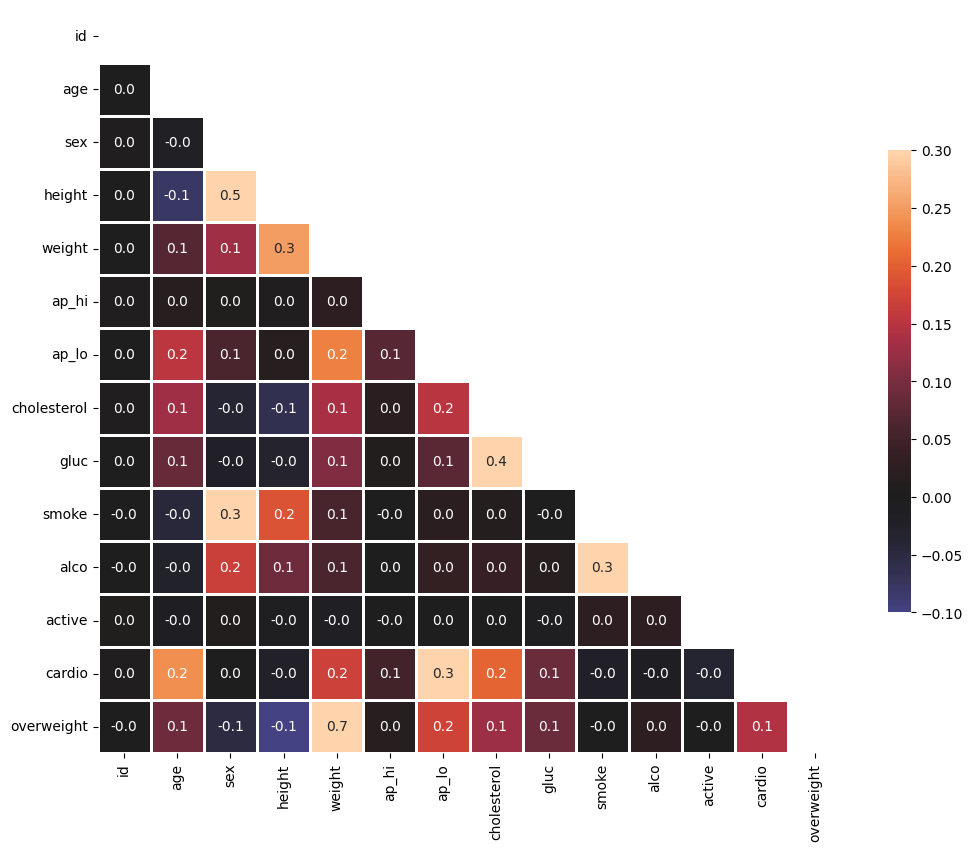

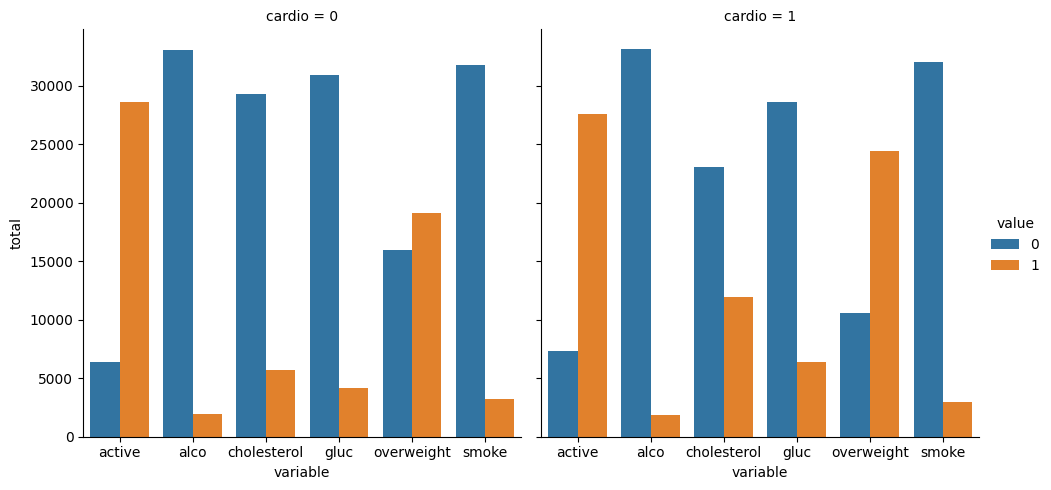

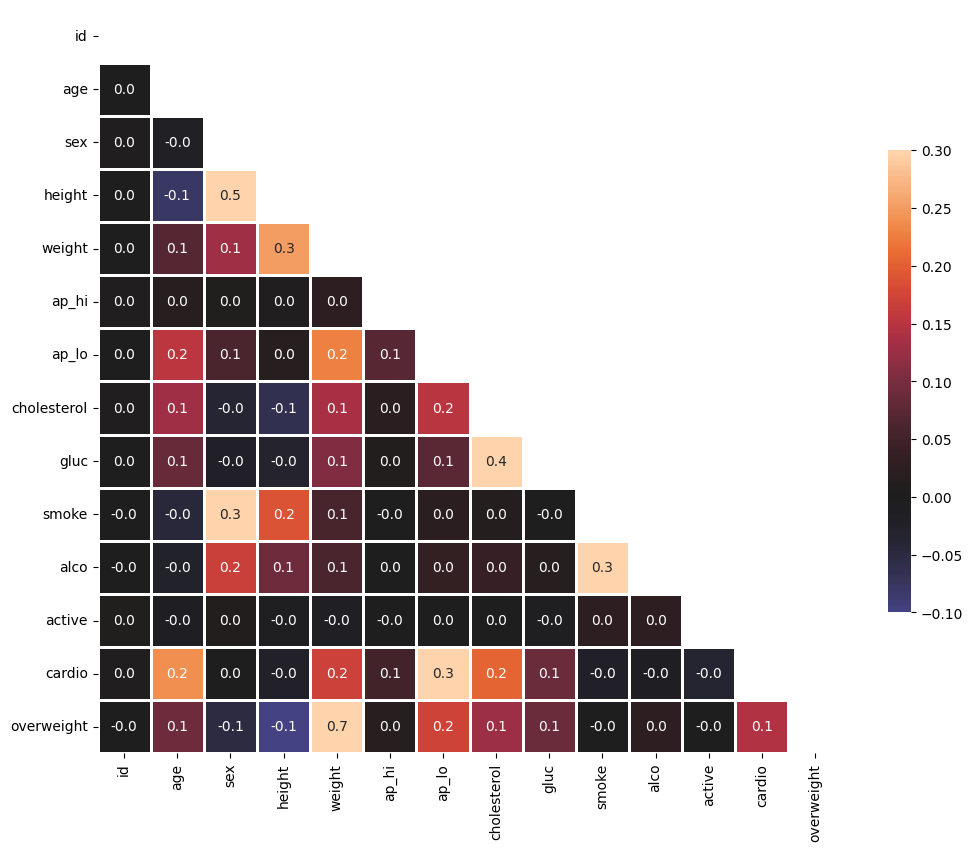

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Import the data from medical_examination.csv and assign it to the df variable
df = pd.read_csv(
    'https://raw.githubusercontent.com/freeCodeCamp/boilerplate-medical-data-visualizer/master/medical_examination.csv'
)

# 2. Add an overweight column to the data
# BMI = weight (kg) / height (m)^2
df['overweight'] = (
    (df['weight'] / ((df['height'] / 100) ** 2) > 25).astype(int)
)

# 3. Normalize data by making 0 always good and 1 always bad
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)


# 4. Draw the Categorical Plot in the draw_cat_plot function
def draw_cat_plot():
  # 5. Create a DataFrame for the cat plot using pd.melt
  df_cat = pd.melt(
      df,
      id_vars=['cardio'],
      value_vars=[
          'active',
          'alco',
          'cholesterol',
          'gluc',
          'overweight',
          'smoke',
      ],
  )

  # 6. Group and reformat the data in df_cat to split it by cardio
  df_cat = (
      df_cat.groupby(['cardio', 'variable', 'value'])
      .size()
      .reset_index(name='total')
  )

  # 7 & 8. Convert data into long format and create chart using sns.catplot()
  fig = sns.catplot(
      x='variable',
      y='total',
      hue='value',
      col='cardio',
      data=df_cat,
      kind='bar',
  ).fig

  # 9. Do not modify the next two lines
  fig.savefig('catplot.png')
  return fig


# 10. Draw the Heat Map in the draw_heat_map function
def draw_heat_map():
  # 11. Clean the data in the df_heat variable
  df_heat = df[
      (df['ap_lo'] <= df['ap_hi'])
      & (df['height'] >= df['height'].quantile(0.025))
      & (df['height'] <= df['height'].quantile(0.975))
      & (df['weight'] >= df['weight'].quantile(0.025))
      & (df['weight'] <= df['weight'].quantile(0.975))
  ]

  # 12. Calculate the correlation matrix
  corr = df_heat.corr()

  # 13. Generate a mask for the upper triangle
  mask = np.triu(corr)

  # 14. Set up the matplotlib figure
  fig, ax = plt.subplots(figsize=(12, 12))

  # 15. Plot the correlation matrix using sns.heatmap()
  sns.heatmap(
      corr,
      mask=mask,
      annot=True,
      fmt='.1f',
      linewidths=1,
      square=True,
      cbar_kws={'shrink': 0.5},
      center=0,
      vmin=-0.1,
      vmax=0.3,
  )

  # 16. Do not modify the next two lines
  fig.savefig('heatmap.png')
  return fig


# ਫੰਕਸ਼ਨਾਂ ਨੂੰ ਚਲਾਉਣ ਲਈ:
draw_cat_plot()
draw_heat_map()